In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('Data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Data\gender_submission.csv
Data\test.csv
Data\train.csv


In [13]:
train_data = pd.read_csv("Data/train.csv")
train_data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
test_data = pd.read_csv("Data/test.csv")
test_data.head()
test_data.PassengerId

0       892
1       893
2       894
3       895
4       896
       ... 
413    1305
414    1306
415    1307
416    1308
417    1309
Name: PassengerId, Length: 418, dtype: int64

In [16]:
women = train_data.loc[train_data.Sex == 'female']["Survived"]
rate_women = sum(women)/len(women)

print("% of women who survived:", rate_women)
print(women)

% of women who survived: 0.7420382165605095
1      1
2      1
3      1
8      1
9      1
      ..
880    1
882    0
885    0
887    1
888    0
Name: Survived, Length: 314, dtype: int64


In [17]:
men = train_data.loc[train_data.Sex == 'male']["Survived"]
rate_men = sum(men)/len(men)

print("% of men who survived:", rate_men)

% of men who survived: 0.18890814558058924


In [18]:
print(train_data.columns)# Check for missing values in each column
missing_data = test_data.isnull().sum()

# Print the columns with missing values
print(missing_data)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


Matplotlib is building the font cache; this may take a moment.


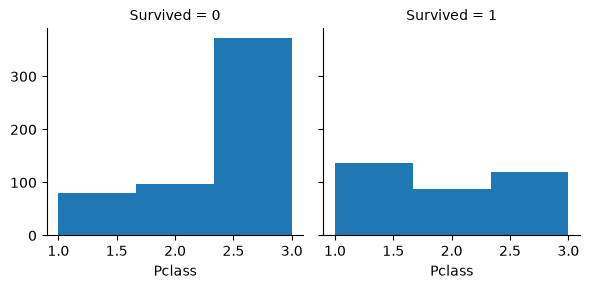

In [26]:
g = sns.FacetGrid(train_data, col='Survived')
g.map(plt.hist, 'Pclass', bins=3)


In [21]:
train_data[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived', ascending=False)


,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


In [27]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
imputer = SimpleImputer(strategy='median')
train_data['Age'] = imputer.fit_transform(train_data[['Age']])
train_data['Fare'] = imputer.fit_transform(train_data[['Fare']])
train_data['CatAge']=pd.cut(train_data['Age'], bins=[0, 4, 16, 40, 75, 85], labels=['infant', 'child', 'young', 'grownup', 'oldest survivor'], right=True)
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch']
train_data['FamilySize'] = pd.cut(train_data['FamilySize'], bins=[-1, 0, 3, 40], labels=['NoFamily', 'SmallFamily', 'BigFamily'], right=True)
train_data['FareCat'] = pd.cut(train_data['Fare'], bins=[-1,7.9 , 14.454 , 31.47, 1000], labels=['cheapFare', 'mediumFare', 'medhighFare', 'expensiveFare'], right=True)
train_data['PclassCat'] = pd.cut(train_data['Pclass'], bins=[0, 1, 2, 3], labels=['1', '2', '3'], right=True)
train_data_selected_features = train_data[['PclassCat', 'Sex', 'CatAge', 'FamilySize', 'FareCat', 'Embarked']]
X = pd.get_dummies(train_data_selected_features)
y = train_data['Survived']
test_data['Age'] = imputer.fit_transform(test_data[['Age']])
test_data['Fare'] = imputer.fit_transform(test_data[['Fare']])
test_data['CatAge']=pd.cut(test_data['Age'], bins=[0, 4, 16, 40, 75, 85], labels=['infant', 'child', 'young', 'grownup', 'oldest survivor'], right=True)
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch']
test_data['FamilySize'] = pd.cut(test_data['FamilySize'], bins=[-1, 0 , 3, 40], labels=['NoFamily', 'SmallFamily', 'BigFamily'], right=True)
test_data['FareCat'] = pd.cut(test_data['Fare'], bins=[-1, 7.9, 14.454, 31.47, 1000], labels=['cheapFare', 'mediumFare', 'medhighFare', 'expensiveFare'], right=True)
test_data['PclassCat'] = pd.cut(test_data['Pclass'], bins=[0, 1, 2, 3], labels=['1', '2', '3'], right=True)
X_test = test_data[['PclassCat', 'Sex', 'CatAge', 'FamilySize', 'FareCat' , 'Embarked']]
X_test = pd.get_dummies(X_test)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}")


lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
print("Accuracy on training set:", lr_model.score(X_val, y_val))
predictions = model.predict(X_test)
# Get the feature importances
importances = model.feature_importances_

# Sort feature importances
sorted_indices = np.argsort(importances)[::-1]

# Print feature importance
for idx in sorted_indices:
    print(f"{X.columns[idx]}: {importances[idx]}")
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")


Validation Accuracy: 0.8101
Accuracy on training set: 0.8100558659217877
Sex_female: 0.49125708885813785
PclassCat_3: 0.14211659568077625
FamilySize_SmallFamily: 0.06769027769062658
CatAge_infant: 0.055729519791420434
FamilySize_BigFamily: 0.04438010859381131
PclassCat_1: 0.03959935799100726
FamilySize_NoFamily: 0.021121105931054613
FareCat_mediumFare: 0.019108621090898573
Embarked_C: 0.017871243278313537
FareCat_cheapFare: 0.015575937379937902
Embarked_S: 0.015340014690806059
CatAge_young: 0.01522318552762008
CatAge_grownup: 0.014280941976214576
FareCat_medhighFare: 0.013436208960145914
CatAge_child: 0.009185811102323393
PclassCat_2: 0.008967054950044922
CatAge_oldest survivor: 0.004296664098704567
FareCat_expensiveFare: 0.0032463977936479744
Embarked_Q: 0.0015738646145081747
Sex_male: 0.0
Your submission was successfully saved!
